# Mounting

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Coding Camp DBS Foundation/Proyek/Submissions/Dataset_clustering.csv")
data.head(20).sort_values(by="price", ascending=False)

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
13,25639.00,Intel Core i5,512 GB,32 GB,Nvidia GeForce RTX 3050,512 GB
3,20799.00,Intel Core i5,256 GB,32 GB,AMD Radeon RX 580,256 GB
16,16865.00,Intel Core i5,256 GB,16 GB,AMD Radeon RX 560,500 GB
8,16499.00,Intel Core i5,256 GB,16 GB,Nvidia GeForce GTX 1650,500 GB
12,14899.00,Intel Core i5,256 GB,16 GB,AMD Radeon RX 580,500 GB
0,13716.90,Intel Core i5,512 GB,16 GB,AMD Radeon RX 550,512 GB
1,13678.00,Intel Core i5,512 GB,16 GB,Nvidia Geforce GT 740,Yok
5,13184.00,NaN,256 GB,NaN,NaN,1 TB
2,12857.74,Intel Core i5,512 GB,16 GB,AMD Radeon RX 580,512 GB
4,12834.62,Intel Core i5,512 GB,16 GB,AMD Radeon RX 550,512 GB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 1.Memahami Struktur data

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2567 entries, 0 to 2566
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              2567 non-null   float64
 1   processor_type     2562 non-null   object 
 2   ssd_capacity       2366 non-null   object 
 3   ram_system_memory  2367 non-null   object 
 4   graphics_card      2562 non-null   object 
 5   capacity           2562 non-null   object 
dtypes: float64(1), object(5)
memory usage: 120.5+ KB


In [5]:
data.isna().sum()

,0
price,0
processor_type,5
ssd_capacity,201
ram_system_memory,200
graphics_card,5
capacity,5


insight:
- dari output di atas dataset terdiri atas 2567 baris dan 5 kolom
- pada kolom ssd capacity terdapat beberapa data kosong
- kolom ssd capacity, ram dan capacity sebaiknya tukar ke bentuk float atau **integer**

In [6]:
data.describe(include="all")

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
count,2567.000000,2562,2366,2367,2562,2562
unique,NaN,13,14,15,50,16
top,NaN,Intel Core i5,4 TB,16 GB,AMD Radeon RX550,Yok
freq,NaN,1600,635,388,503,907
mean,33388.716767,NaN,NaN,NaN,NaN,NaN
std,18977.857381,NaN,NaN,NaN,NaN,NaN
min,2649.000000,NaN,NaN,NaN,NaN,NaN
25%,26123.600000,NaN,NaN,NaN,NaN,NaN
50%,32999.990000,NaN,NaN,NaN,NaN,NaN
75%,39334.075000,NaN,NaN,NaN,NaN,NaN


## 2.Menangani Data yang Hilang

Melakukan imputation data mdengan data yang sering keluar dari dataset

In [7]:

data['processor_type'] = data['processor_type'].fillna(data['processor_type'].mode()[0])
data['graphics_card'] = data['graphics_card'].fillna(data['graphics_card'].mode()[0])
# Fungsi untuk mengisi NaN dengan sampel acak dari data yang ada
def fillna_random(df, column):
    df[column] = df[column].apply(lambda x: np.random.choice(df[column].dropna().values) if pd.isna(x) else x)

# Isi NaN secara acak
fillna_random(data, 'capacity')
fillna_random(data, 'ram_system_memory')
fillna_random(data, 'ssd_capacity')

# Check if there are any missing values left in 'Processor Type'
data.isna().sum()


,0
price,0
processor_type,0
ssd_capacity,0
ram_system_memory,0
graphics_card,0
capacity,0


setelah mengetahui bahwa ada data yang hilang, saya melakukan imputasi berdasatkan modus dari dataset

## 3.Analisis Distribusi dan Korelasi

In [8]:
data.describe(include="all")

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
count,2567.000000,2567,2567,2567,2567,2567
unique,NaN,13,14,15,50,16
top,NaN,Intel Core i5,4 TB,16 GB,AMD Radeon RX550,Yok
freq,NaN,1605,684,418,508,909
mean,33388.716767,NaN,NaN,NaN,NaN,NaN
std,18977.857381,NaN,NaN,NaN,NaN,NaN
min,2649.000000,NaN,NaN,NaN,NaN,NaN
25%,26123.600000,NaN,NaN,NaN,NaN,NaN
50%,32999.990000,NaN,NaN,NaN,NaN,NaN
75%,39334.075000,NaN,NaN,NaN,NaN,NaN


In [9]:
data.groupby('graphics_card').agg({
    'price': 'max'
})

,price
graphics_card,
AMD CPU Entegre Grafik,22299.00
AMD Radeon Graphics,53337.27
AMD Radeon R5,9149.00
AMD Radeon R5 230,21268.00
AMD Radeon R7 240,11999.00
AMD Radeon RX 550,64499.49
AMD Radeon RX 550X,18308.07
AMD Radeon RX 560,16865.00
AMD Radeon RX 570,48999.99


Karena ada tiga kolom yang belum di ubah menjadi numerik yaitu kolom ssd_capacity, ram_system_memory dan capacity.

sebaiknya data diubh menjadi numerik dahulu.

### Mengubah data kolom SSD, RAM dan Capacity sebelun masuk ke visualisasi

In [10]:

def convert(value):
    if isinstance(value, str):
        if 'TB' in value:
            return float(value.replace('TB', '')) * 1024
        elif 'GB' in value:
            return float(value.replace('GB', ''))
        elif 'Yok'in value or 'yok' in value:
            return 0
    return

# Convert the columns to integer type
data['ssd_capacity'] = data['ssd_capacity'].apply(convert)
data['ram_system_memory'] = data['ram_system_memory'].apply(convert)
data['capacity'] = data['capacity'].apply(convert)


In [11]:
data.describe(include="all")

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
count,2567.000000,2567,2567.000000,2567.000000,2567,2536.000000
unique,NaN,13,NaN,NaN,50,NaN
top,NaN,Intel Core i5,NaN,NaN,AMD Radeon RX550,NaN
freq,NaN,1605,NaN,NaN,508,NaN
mean,33388.716767,NaN,1768.710557,30.694196,NaN,920.447950
std,18977.857381,NaN,1520.874365,19.553940,NaN,1286.946996
min,2649.000000,NaN,0.000000,4.000000,NaN,0.000000
25%,26123.600000,NaN,512.000000,16.000000,NaN,0.000000
50%,32999.990000,NaN,1024.000000,24.000000,NaN,256.000000
75%,39334.075000,NaN,4096.000000,40.000000,NaN,1024.000000


In [12]:
data['capacity'] = data['capacity'].fillna(data['capacity'].iloc[0])

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2567 entries, 0 to 2566
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              2567 non-null   float64
 1   processor_type     2567 non-null   object 
 2   ssd_capacity       2567 non-null   float64
 3   ram_system_memory  2567 non-null   float64
 4   graphics_card      2567 non-null   object 
 5   capacity           2567 non-null   float64
dtypes: float64(4), object(2)
memory usage: 120.5+ KB


setelah melakukan imputasi dan pengubahan nilai dari string menjadi nuber dari beberapa kolom dataset siap untuk di visualisaiskan

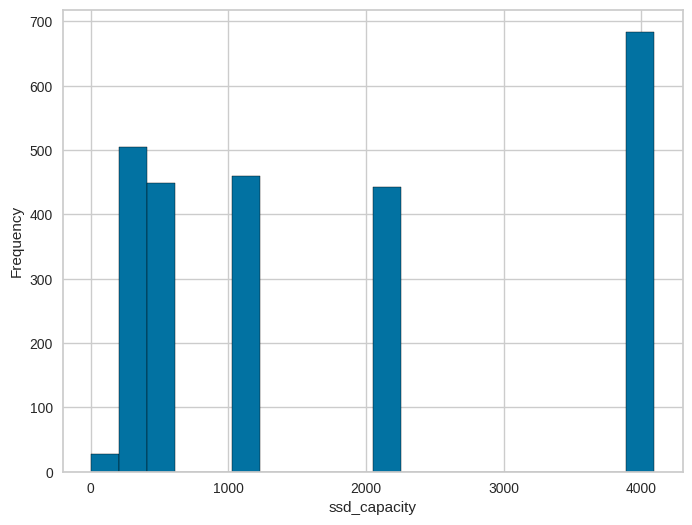

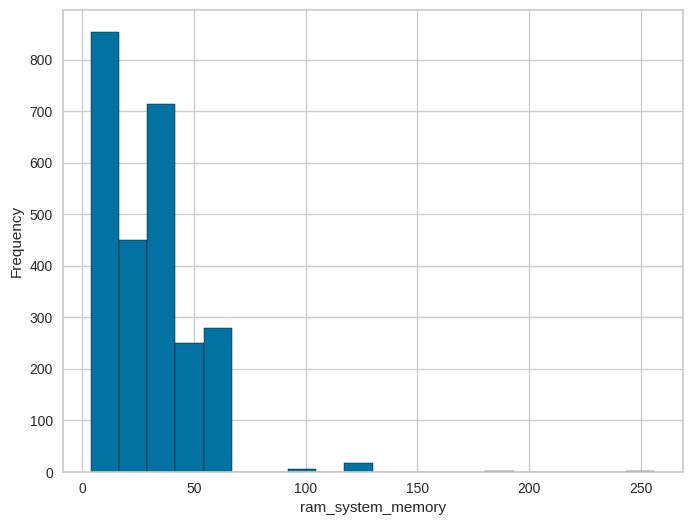

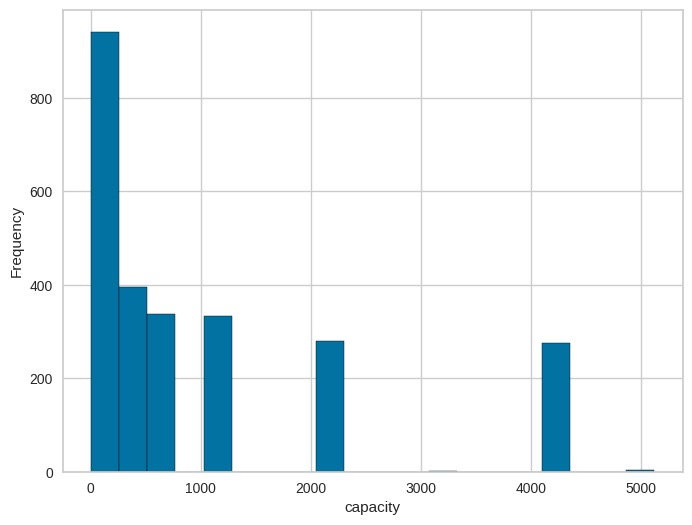

In [14]:

numerical_cols = ['ssd_capacity', 'ram_system_memory', 'capacity']

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    plt.hist(data[col], bins=20, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


melihat dari distribusi data di atas terlihat bahwa data cukup terbagi dengan rata

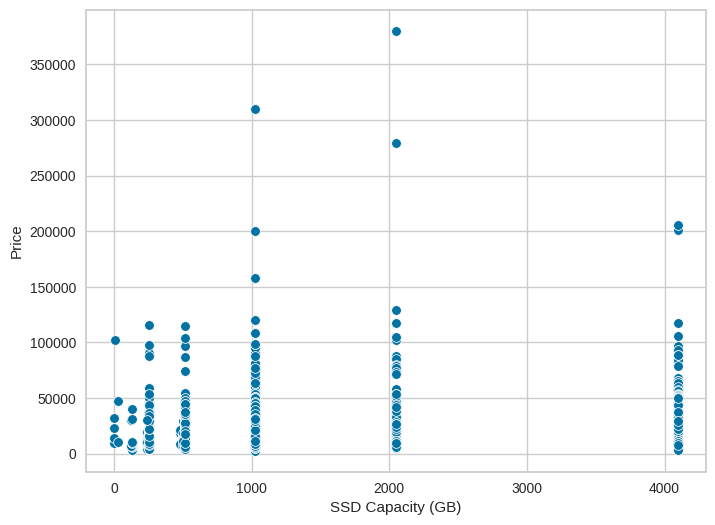

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(y='price', x='ssd_capacity', data=data)
plt.ylabel('Price')
plt.xlabel('SSD Capacity (GB)')
plt.show()


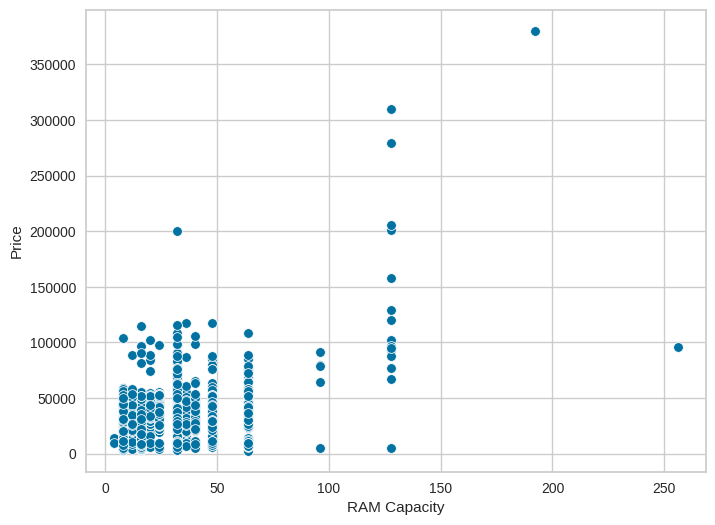

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(y='price', x='ram_system_memory', data=data)
plt.ylabel('Price')
plt.xlabel('RAM Capacity')
plt.show()


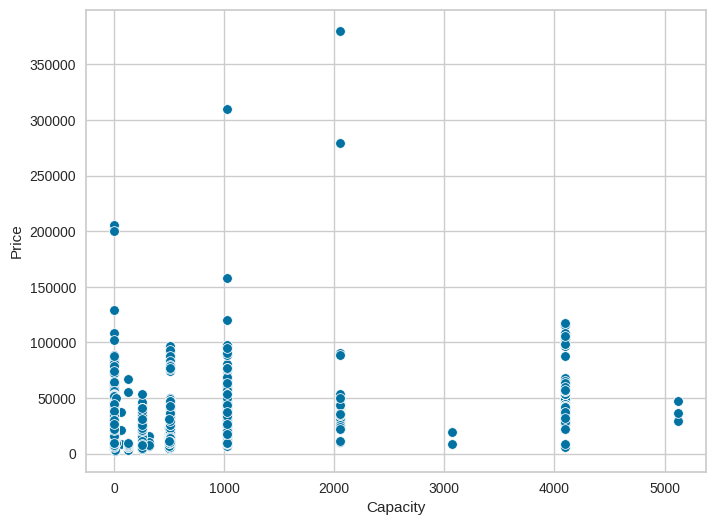

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(y='price', x='capacity', data=data)
plt.ylabel('Price')
plt.xlabel('Capacity')
plt.show()


dari beberapa scatterplot di atas nampak bahwa harga tidak selalu terpengaruh oleh kapasitas dari RAM SSD dan penyimpanannya.

sebaiknya melakukan visualisasi dari data kategorikal

## 4.Visualisasi Data

In [18]:
data.head()

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
0,13716.90,Intel Core i5,512.0,16.0,AMD Radeon RX 550,512.0
1,13678.00,Intel Core i5,512.0,16.0,Nvidia Geforce GT 740,0.0
2,12857.74,Intel Core i5,512.0,16.0,AMD Radeon RX 580,512.0
3,20799.00,Intel Core i5,256.0,32.0,AMD Radeon RX 580,256.0
4,12834.62,Intel Core i5,512.0,16.0,AMD Radeon RX 550,512.0


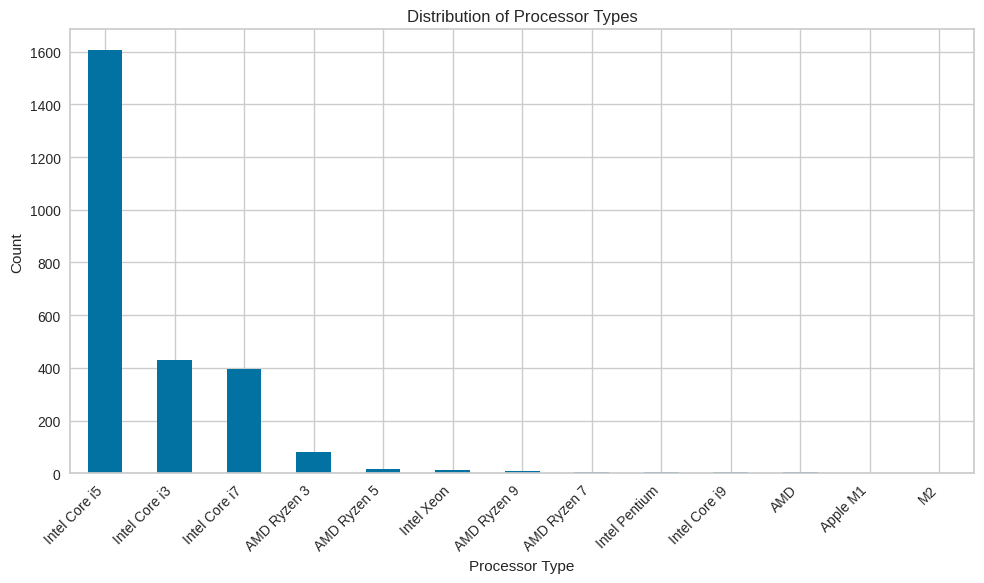

In [19]:

plt.figure(figsize=(10, 6))
data['processor_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Processor Types')
plt.xlabel('Processor Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



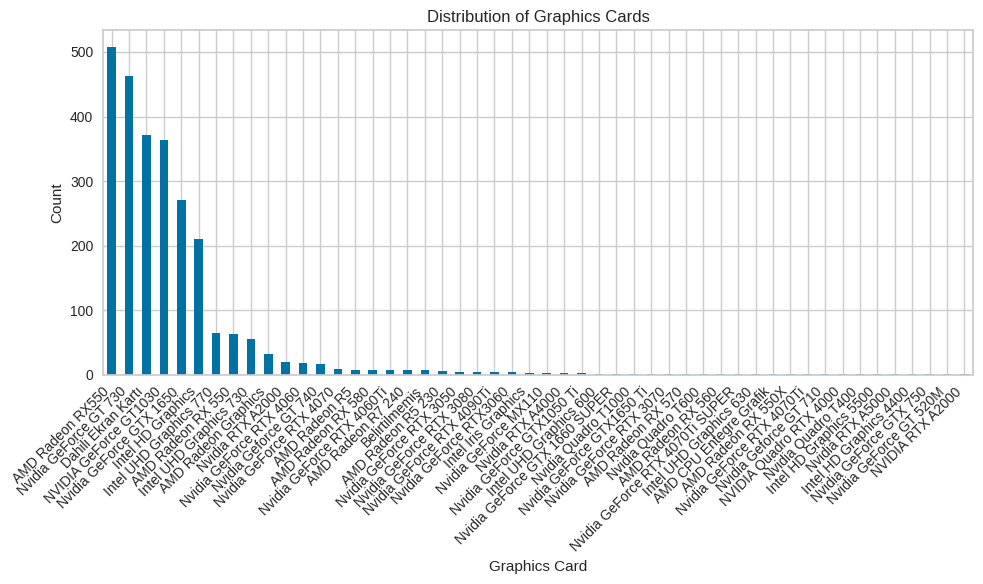

In [20]:

plt.figure(figsize=(10, 6))
data['graphics_card'].value_counts().plot(kind='bar')
plt.title('Distribution of Graphics Cards')
plt.xlabel('Graphics Card')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2567 entries, 0 to 2566
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              2567 non-null   float64
 1   processor_type     2567 non-null   object 
 2   ssd_capacity       2567 non-null   float64
 3   ram_system_memory  2567 non-null   float64
 4   graphics_card      2567 non-null   object 
 5   capacity           2567 non-null   float64
dtypes: float64(4), object(2)
memory usage: 120.5+ KB


Data kosong telah teratasi dengan baik

In [22]:
data.duplicated().sum()

np.int64(1)

Tidak ada data duplikan

## Normalisasi dan standarisasi fitur

In [23]:


# Menentukan kolom yang akan di-scale menggunakan Robust Scaling
robust_cols = ['ssd_capacity', 'ram_system_memory', 'capacity', 'price']

# Inisialisasi RobustScaler
scaler = RobustScaler()

# Menerapkan Robust Scaling pada kolom yang dipilih
data[robust_cols] = scaler.fit_transform(data[robust_cols])

# Menampilkan hasil
data.head()


,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
0,-1.459682,Intel Core i5,-0.142857,-0.333333,AMD Radeon RX 550,0.25
1,-1.462626,Intel Core i5,-0.142857,-0.333333,Nvidia Geforce GT 740,-0.25
2,-1.524718,Intel Core i5,-0.142857,-0.333333,AMD Radeon RX 580,0.25
3,-0.923585,Intel Core i5,-0.214286,0.333333,AMD Radeon RX 580,0.00
4,-1.526468,Intel Core i5,-0.142857,-0.333333,AMD Radeon RX 550,0.25


## Encoding Data Kategorikal


In [24]:
# Assuming 'data' DataFrame contains 'processor_type'
df_processor = data[['processor_type']].copy()

# Create a new column 'processor_encoded' using LabelEncoder
label_encoder = LabelEncoder()
df_processor['processor_encoded'] = label_encoder.fit_transform(df_processor['processor_type'])


# Similar process for 'graphics_card'
df_graphics = data[['graphics_card']].copy()
label_encoder_graphics = LabelEncoder()  # Use a separate encoder for graphics card
df_graphics['graphics_encoded'] = label_encoder_graphics.fit_transform(df_graphics['graphics_card'])

# Now you can proceed with the original code:
processor_mapping = dict(zip(df_processor['processor_type'], df_processor['processor_encoded']))
graphics_mapping = dict(zip(df_graphics['graphics_card'], df_graphics['graphics_encoded']))

# Menerapkan encoding pada data utama
data["processor_type"] = data["processor_type"].map(processor_mapping)
data["graphics_card"] = data["graphics_card"].map(graphics_mapping)

# Menampilkan hasil
data.head()

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
0,-1.459682,7,-0.142857,-0.333333,5,0.25
1,-1.462626,7,-0.142857,-0.333333,43,-0.25
2,-1.524718,7,-0.142857,-0.333333,9,0.25
3,-0.923585,7,-0.214286,0.333333,9,0.00
4,-1.526468,7,-0.142857,-0.333333,5,0.25


In [25]:
data.describe()

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity
count,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000
mean,0.029426,6.773276,0.207788,0.278925,17.967667,0.644058
std,1.436576,1.341241,0.424351,0.814747,8.283517,1.249929
min,-2.297494,0.000000,-0.285714,-0.833333,0.000000,-0.250000
25%,-0.520526,7.000000,-0.142857,-0.333333,11.500000,-0.250000
50%,0.000000,7.000000,0.000000,0.000000,19.000000,0.000000
75%,0.479474,7.000000,0.857143,0.666667,25.000000,0.750000
max,26.293783,12.000000,0.857143,9.666667,49.000000,4.750000


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

### Pengembangan Model 1

In [26]:
X_dbscan = data.copy()
X_dbscan.head()

dbscan = DBSCAN(eps=0.5, min_samples=1)  # Adjust eps and min_samples as needed
X_dbscan['cluster_dbscan'] = dbscan.fit_predict(X_dbscan)
X_dbscan.describe()


,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity,cluster_dbscan
count,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000
mean,0.029426,6.773276,0.207788,0.278925,17.967667,0.644058,212.005843
std,1.436576,1.341241,0.424351,0.814747,8.283517,1.249929,117.884653
min,-2.297494,0.000000,-0.285714,-0.833333,0.000000,-0.250000,0.000000
25%,-0.520526,7.000000,-0.142857,-0.333333,11.500000,-0.250000,149.500000
50%,0.000000,7.000000,0.000000,0.000000,19.000000,0.000000,202.000000
75%,0.479474,7.000000,0.857143,0.666667,25.000000,0.750000,281.000000
max,26.293783,12.000000,0.857143,9.666667,49.000000,4.750000,525.000000


<h4> Kesimpulan Hasil Clustering Awal dengan DBSCAN

Pada tahap eksplorasi awal, model clustering DBSCAN diterapkan dengan parameter `eps=0.5` dan `min_samples=1`. Hasilnya menunjukkan bahwa DBSCAN berhasil mengelompokkan seluruh data menjadi **526 cluster**, dengan nilai rata-rata label cluster sebesar **213.3** dan standar deviasi yang tinggi (**122.8**). Ini mengindikasikan bahwa model cenderung membentuk **banyak cluster kecil**, bahkan berpotensi satu data satu cluster (singleton).

Karena `min_samples` diset ke 1, **semua titik dianggap sebagai bagian dari cluster**, sehingga tidak ada noise yang terdeteksi. Ini menyebabkan hasil clustering kurang representatif terhadap pola nyata dalam data.

Secara umum, hasil ini memberikan **gambaran awal distribusi dan sensitivitas model terhadap parameter**, namun belum optimal untuk interpretasi makna kelompok. Diperlukan **penyesuaian parameter (tuning eps dan min_samples)** serta **visualisasi** untuk mendapatkan hasil clustering yang lebih bermakna dan bisa dijadikan dasar analisis lebih lanjut.



### Pengembangan Model 2


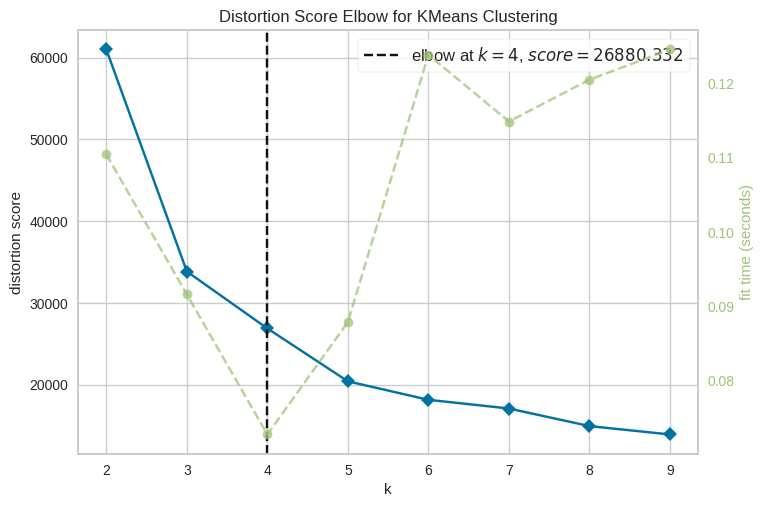

Optimal number of clusters: 4


,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity,cluster
0,-1.459682,7,-0.142857,-0.333333,5,0.25,1
1,-1.462626,7,-0.142857,-0.333333,43,-0.25,0
2,-1.524718,7,-0.142857,-0.333333,9,0.25,1
3,-0.923585,7,-0.214286,0.333333,9,0.00,1
4,-1.526468,7,-0.142857,-0.333333,5,0.25,1


In [27]:


# Membuat salinan data untuk clustering
X_kmeans = data.copy()

# Inisialisasi model K-Means
kmeans = KMeans(init="k-means++", max_iter=300, n_init=10, random_state=42)

# Menggunakan KElbowVisualizer untuk menentukan jumlah klaster optimal
visualizer = KElbowVisualizer(kmeans, k=(2, 10))
visualizer.fit(X_kmeans)

# Menampilkan hasil visualisasi
visualizer.show()

# Mendapatkan jumlah klaster optimal dari Elbow Method
optimal_k = visualizer.elbow_value_
print(f"Optimal number of clusters: {optimal_k}")

# Menerapkan K-Means dengan jumlah klaster optimal
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", max_iter=300, n_init=10, random_state=42)
X_kmeans["cluster"] = kmeans.fit_predict(X_kmeans)

# Menampilkan beberapa baris pertama dari hasil klasterisasi
X_kmeans.head()


<h4> Kesimpulan Hasil Clustering Awal dengan K-Means

Eksperimen awal dengan algoritma K-Means dilakukan untuk mengelompokkan data berdasarkan fitur yang telah dinormalisasi. Untuk menentukan jumlah klaster optimal, digunakan metode **Elbow Method** melalui `KElbowVisualizer`. Berdasarkan grafik elbow, jumlah klaster optimal yang diperoleh adalah **4**.

Model K-Means kemudian dijalankan dengan parameter:
- `n_clusters=4`
- `init="k-means++"`
- `max_iter=300`
- `n_init=10`
- `random_state=42`

Hasil klasterisasi menunjukkan bahwa data berhasil terbagi menjadi **4 kelompok utama**. Berdasarkan sampel data hasil klasterisasi, terlihat bahwa klaster-klaster terbentuk berdasarkan kombinasi nilai `price`, `graphics_card`, `capacity`, dan fitur lainnya.

Clustering ini memberi gambaran awal tentang **struktur segmentasi dalam dataset**, dan hasilnya lebih terstruktur dibandingkan pendekatan DBSCAN sebelumnya yang menghasilkan ratusan cluster kecil. Selanjutnya, diperlukan:
- **Visualisasi distribusi klaster** (misalnya dengan PCA atau t-SNE),
- **Evaluasi klaster (seperti Silhouette Score)**,
- dan interpretasi karakteristik dari masing-masing klaster.

Langkah ini menjadi dasar penting untuk segmentasi data yang lebih bermakna secara bisnis atau teknis.


## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

### Evaluasi Model 1

In [28]:
dbscan_score = silhouette_score(X_dbscan.drop(columns='cluster_dbscan'), X_dbscan['cluster_dbscan'])
print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")


DBSCAN Silhouette Score: 0.2768


<h3> Evaluasi Model 1: DBSCAN

Model DBSCAN dievaluasi menggunakan **Silhouette Score** untuk mengukur kualitas pemisahan antar cluster. Hasil evaluasi menunjukkan:

- **Silhouette Score (DBSCAN):** `0.2717`

Nilai ini tergolong **rendah**, mengindikasikan bahwa cluster yang terbentuk **kurang kohesif dan memiliki overlap antar cluster**. Hal ini kemungkinan disebabkan oleh pemilihan parameter awal seperti `eps=0.5` dan `min_samples=1`, yang menyebabkan terlalu banyak cluster kecil (over-segmentation). DBSCAN juga kurang optimal dalam data dengan kepadatan yang seragam.

---


### Evaluasi Model 2

In [29]:
kmeans_score = silhouette_score(X_kmeans.drop(columns='cluster'), X_kmeans['cluster'])
print(f"KMeans Silhouette Score: {kmeans_score:.4f}")


KMeans Silhouette Score: 0.5577



<h3> Evaluasi Model 2: K-Means

Model K-Means dijalankan dengan jumlah klaster optimal (`k=4`) yang ditentukan menggunakan Elbow Method. Hasil evaluasi dengan Silhouette Score adalah:

- **Silhouette Score (K-Means):** `0.5581`

Nilai ini tergolong **cukup baik**, menunjukkan bahwa K-Means mampu membentuk cluster yang **lebih jelas terpisah dan lebih kohesif** dibandingkan DBSCAN pada data ini. Kinerja ini cocok dengan asumsi dasar K-Means yang lebih optimal untuk data dengan cluster berbentuk bulat (spherical) dan ukuran relatif seragam.

---

<h3> Perbandingan Keseluruhan

Berdasarkan perbandingan **Silhouette Score**:
- `KMeans (0.5581) > DBSCAN (0.2717)`

Dapat disimpulkan bahwa **K-Means memberikan hasil clustering yang lebih baik dibandingkan DBSCAN** dalam eksperimen ini. Ini menjadikan K-Means sebagai kandidat yang lebih kuat untuk tahap eksplorasi lanjutan atau segmentasi data.


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [30]:
selector = VarianceThreshold(threshold=0.2)  # Hapus fitur dengan variansi rendah
X_reduced = selector.fit_transform(data)
selected_features = data.columns[selector.get_support()]

print("Fitur yang dipilih:", list(selected_features))


Fitur yang dipilih: ['price', 'processor_type', 'ram_system_memory', 'graphics_card', 'capacity']


In [31]:
X_selected = data[selected_features]
X_selected.head()

,price,processor_type,ram_system_memory,graphics_card,capacity
0,-1.459682,7,-0.333333,5,0.25
1,-1.462626,7,-0.333333,43,-0.25
2,-1.524718,7,-0.333333,9,0.25
3,-0.923585,7,0.333333,9,0.00
4,-1.526468,7,-0.333333,5,0.25


In [32]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_selected)

X_selected= pd.DataFrame(X_pca)
X_selected.head()

,0,1
0,-13.034775,-0.647752
1,24.890428,-3.033755
2,-9.045344,-0.929437
3,-9.009675,-0.386947
4,-13.038400,-0.700559


## Pengembangan Model 1 (feature selection)

In [33]:
df_dbscan = X_selected.copy()
dbscan_selected = DBSCAN(eps=0.5, min_samples=1)  # Adjust eps and min_samples as needed
df_dbscan['cluster_dbscan'] = dbscan_selected.fit_predict(df_dbscan)
df_dbscan.describe()

,0,1,cluster_dbscan
count,2.567000e+03,2.567000e+03,2567.000000
mean,4.650221e-15,-3.321587e-17,18.980522
std,8.297662e+00,1.481662e+00,23.722915
min,-1.809836e+01,-4.439310e+00,0.000000
25%,-6.577180e+00,-8.046254e-01,4.000000
50%,1.060816e+00,-1.691593e-01,6.000000
75%,7.009035e+00,6.425650e-01,31.000000
max,3.255308e+01,2.275048e+01,101.000000


## Evaluasi Model 1 (feature selection)

In [34]:
selected_dbscan_score = silhouette_score(df_dbscan, df_dbscan['cluster_dbscan'])
print(f"DBSCAN Silhouette Score: {selected_dbscan_score}")



DBSCAN Silhouette Score: 0.6772479886941696


<h2> Pengembangan dan Evaluasi Model 1 (Feature Selection)

Pengembangan Model <br>
Model DBSCAN diterapkan pada data hasil feature selection menggunakan parameter `eps=0.5` dan `min_samples=1`. Pendekatan ini bertujuan untuk mengelompokkan data berdasarkan densitas, yang memungkinkan pendeteksian cluster dengan bentuk tidak beraturan serta outlier.

Evaluasi Model
- **Silhouette Score (DBSCAN)**: **0.6772**

 Kesimpulan <br>
Model DBSCAN pada data yang telah mengalami feature selection menghasilkan skor Silhouette sebesar **0.6772**, yang menunjukkan kualitas klasterisasi yang **cukup baik**. Nilai ini mengindikasikan bahwa pemisahan antar cluster cukup jelas dan objek-objek dalam cluster saling mirip. Dengan parameter ini, DBSCAN menunjukkan performa kompetitif pada data yang telah disederhanakan fiturnya.


## Pengembangan Model 2 (feature selection)

Optimal number of clusters: 4


,0,1,cluster
0,-13.034775,-0.647752,1
1,24.890428,-3.033755,3
2,-9.045344,-0.929437,1
3,-9.009675,-0.386947,1
4,-13.038400,-0.700559,1


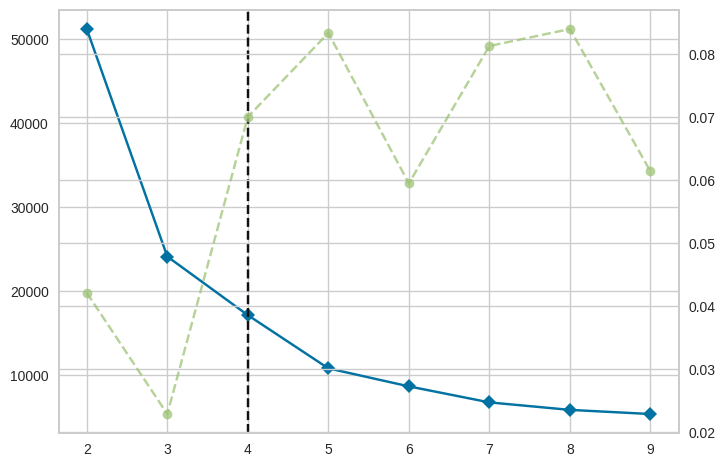

In [35]:

kmeans_df = X_selected.copy()

kmeans = KMeans(init="k-means++", max_iter=500, n_init=10, random_state=42)

visualizer = KElbowVisualizer(kmeans, k=(2, 10))
visualizer.fit(kmeans_df)

optimal_k = visualizer.elbow_value_
print(f"Optimal number of clusters: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", max_iter=500, n_init=10, random_state=42)
kmeans_df["cluster"] = kmeans.fit_predict(kmeans_df)

kmeans_df.head()


## Evaluasi Model 2 (feature selection)

In [36]:
selected_kmeans_score = silhouette_score(kmeans_df.drop(columns='cluster'), kmeans_df['cluster'])
print(f"KMeans Silhouette Score (after feature selection): {selected_kmeans_score:.4f}")


if selected_kmeans_score > selected_dbscan_score:
    print("KMeans performs better than DBSCAN based on silhouette score.")
elif selected_dbscan_score > selected_kmeans_score:
    print("DBSCAN performs better than KMeans based on silhouette score.")

comparison_score_kmeans = selected_kmeans_score - kmeans_score
comparison_score_dbscan = selected_dbscan_score - dbscan_score


print(f"Comparison Score (KMeans): {comparison_score_kmeans}")
print(f"Comparison Score (DBSCAN): {comparison_score_dbscan}")

KMeans Silhouette Score (after feature selection): 0.6910
KMeans performs better than DBSCAN based on silhouette score.
Comparison Score (KMeans): 0.1333006917044437
Comparison Score (DBSCAN): 0.40045023173204314


<h2> Pengembangan dan Evaluasi Model 2 (Feature Selection)

 Pengembangan Model <br>
Model KMeans diterapkan pada data hasil feature selection. Proses penentuan jumlah cluster optimal dilakukan menggunakan **Elbow Method**, dengan hasil:
- **Jumlah cluster optimal:** 4

Setelah itu, model KMeans diinisialisasi ulang dengan jumlah cluster optimal dan digunakan untuk mengklaster data.

 Evaluasi Model
- **KMeans Silhouette Score (setelah feature selection):** **0.6910**

Perbandingan dengan DBSCAN <br>
Model ini dibandingkan dengan DBSCAN yang juga dijalankan pada data hasil feature selection. Hasil perbandingan sebagai berikut:

- **KMeans Silhouette Score:** 0.6910  
- **DBSCAN Silhouette Score:** 0.6772  

**KMeans memiliki performa lebih baik** dibanding DBSCAN berdasarkan nilai Silhouette Score setelah feature selection.

Peningkatan dari Model Sebelumnya  <br>
Jika dibandingkan dengan hasil model sebelum feature selection:
- **KMeans** mengalami peningkatan skor sebesar **0.1333**
- **DBSCAN** mengalami peningkatan skor sebesar **0.4004**

Kesimpulan <br>
Feature selection memberikan dampak signifikan dalam meningkatkan performa kedua model, terutama DBSCAN. Namun, pada akhirnya **KMeans unggul sedikit** dalam hal kualitas klasterisasi setelah feature selection, menjadikannya pilihan yang lebih optimal dalam konteks ini.


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

In [37]:
kmeans_df.describe()

,0,1,cluster
count,2.567000e+03,2.567000e+03,2567.000000
mean,4.650221e-15,-3.321587e-17,1.176860
std,8.297662e+00,1.481662e+00,0.777636
min,-1.809836e+01,-4.439310e+00,0.000000
25%,-6.577180e+00,-8.046254e-01,1.000000
50%,1.060816e+00,-1.691593e-01,1.000000
75%,7.009035e+00,6.425650e-01,2.000000
max,3.255308e+01,2.275048e+01,3.000000


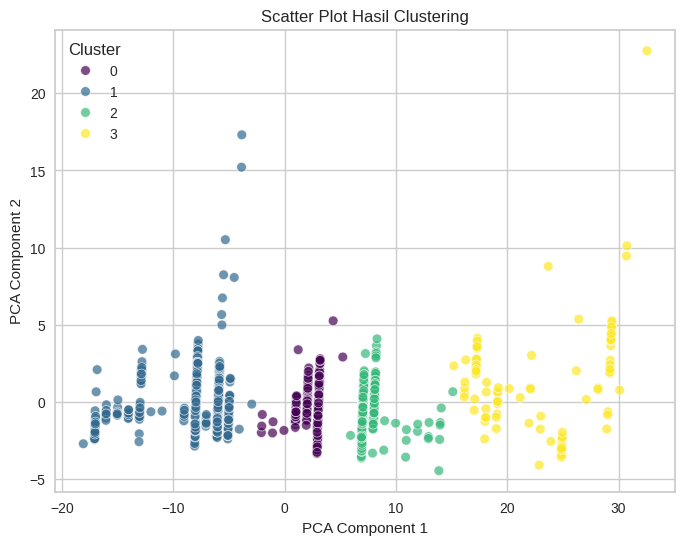

In [38]:
# Pastikan tidak ada kolom hasil clustering dalam data sebelum reduksi dimensi
X_cluster = kmeans_df.drop(columns=['cluster'])

# Reduksi dimensi ke 2D menggunakan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

# Buat scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_df['cluster'], palette="viridis", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Scatter Plot Hasil Clustering")
plt.legend(title="Cluster")
plt.show()


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [39]:
data['cluster'] = kmeans.labels_
data.head()


,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity,cluster
0,-1.459682,7,-0.142857,-0.333333,5,0.25,1
1,-1.462626,7,-0.142857,-0.333333,43,-0.25,3
2,-1.524718,7,-0.142857,-0.333333,9,0.25,1
3,-0.923585,7,-0.214286,0.333333,9,0.00,1
4,-1.526468,7,-0.142857,-0.333333,5,0.25,1


In [40]:
# Membalikkan mapping dictionary untuk decoding
inverse_processor_mapping = {v: k for k, v in processor_mapping.items()}
inverse_graphics_mapping = {v: k for k, v in graphics_mapping.items()}

# Mengembalikan hasil encoding ke nilai asli
data["processor_type"] = data["processor_type"].map(inverse_processor_mapping)
data["graphics_card"] = data["graphics_card"].map(inverse_graphics_mapping)

# Menampilkan hasil
data.head()


,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity,cluster
0,-1.459682,Intel Core i5,-0.142857,-0.333333,AMD Radeon RX 550,0.25,1
1,-1.462626,Intel Core i5,-0.142857,-0.333333,Nvidia Geforce GT 740,-0.25,3
2,-1.524718,Intel Core i5,-0.142857,-0.333333,AMD Radeon RX 580,0.25,1
3,-0.923585,Intel Core i5,-0.214286,0.333333,AMD Radeon RX 580,0.00,1
4,-1.526468,Intel Core i5,-0.142857,-0.333333,AMD Radeon RX 550,0.25,1


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [41]:
data[['ssd_capacity', 'ram_system_memory', 'capacity', 'price']] = scaler.inverse_transform(data[['ssd_capacity', 'ram_system_memory', 'capacity', 'price']])
data.head()

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity,cluster
0,13716.90,Intel Core i5,512.0,16.0,AMD Radeon RX 550,512.0,1
1,13678.00,Intel Core i5,512.0,16.0,Nvidia Geforce GT 740,0.0,3
2,12857.74,Intel Core i5,512.0,16.0,AMD Radeon RX 580,512.0,1
3,20799.00,Intel Core i5,256.0,32.0,AMD Radeon RX 580,256.0,1
4,12834.62,Intel Core i5,512.0,16.0,AMD Radeon RX 550,512.0,1


Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2567 entries, 0 to 2566
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              2567 non-null   float64
 1   processor_type     2567 non-null   object 
 2   ssd_capacity       2567 non-null   float64
 3   ram_system_memory  2567 non-null   float64
 4   graphics_card      2567 non-null   object 
 5   capacity           2567 non-null   float64
 6   cluster            2567 non-null   int32  
dtypes: float64(4), int32(1), object(2)
memory usage: 130.5+ KB


In [51]:
grouped = data.groupby('cluster').agg({
    'processor_type': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'graphics_card': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'ssd_capacity': 'mean',
    'ram_system_memory': 'mean',
    'capacity': 'mean',
}).reset_index()

grouped.head()

,cluster,processor_type,graphics_card,ssd_capacity,ram_system_memory,capacity
0,0,Intel Core i5,NVIDIA GeForce GT1030,1863.747967,30.951220,1028.682927
1,1,Intel Core i5,AMD Radeon RX550,1697.938010,29.164763,808.543230
2,2,Intel Core i5,Nvidia GeForce GT 730,1851.212766,31.292553,983.289894
3,3,Intel Core i7,Nvidia RTX A2000,1541.567010,44.082474,1168.123711


In [52]:
grouped.describe(include="all")

,cluster,processor_type,graphics_card,ssd_capacity,ram_system_memory,capacity
count,4.000000,4,4,4.000000,4.000000,4.000000
unique,NaN,2,4,NaN,NaN,NaN
top,NaN,Intel Core i5,NVIDIA GeForce GT1030,NaN,NaN,NaN
freq,NaN,3,1,NaN,NaN,NaN
mean,1.500000,NaN,NaN,1738.616438,33.872753,997.159940
std,1.290994,NaN,NaN,151.458514,6.870137,148.313802
min,0.000000,NaN,NaN,1541.567010,29.164763,808.543230
25%,0.750000,NaN,NaN,1658.845260,30.504605,939.603228
50%,1.500000,NaN,NaN,1774.575388,31.121886,1005.986410
75%,2.250000,NaN,NaN,1854.346566,34.490033,1063.543123


## Analisis Karakteristik Cluster dari Model KMeans

### Cluster 0
- **Processor Dominan**: Intel Core i5  
- **Graphics Card Dominan**: NVIDIA GeForce GT1030  
- **Rata-rata SSD Capacity**: 1863.75 GB  
- **Rata-rata RAM**: 30.95 GB  
- **Rata-rata Kapasitas**: 1028.68  
- **Analisis**: Cluster ini berisi laptop dengan spesifikasi menengah, RAM besar dan SSD mendekati 2 TB. GPU GT1030 menunjukkan bahwa laptop ini cocok untuk multitasking dan penggunaan ringan hingga sedang. Cocok untuk pengguna kantoran atau pelajar dengan kebutuhan tinggi.

### Cluster 1
- **Processor Dominan**: Intel Core i5  
- **Graphics Card Dominan**: AMD Radeon RX550  
- **Rata-rata SSD Capacity**: 1697.94 GB  
- **Rata-rata RAM**: 29.16 GB  
- **Rata-rata Kapasitas**: 808.54  
- **Analisis**: Cluster ini juga mewakili kelas menengah, dengan SSD cukup besar (~1.7 TB) dan GPU AMD RX550 yang bisa menangani kebutuhan grafis ringan hingga sedang. RAM 29 GB cukup tinggi untuk produktivitas.

### Cluster 2
- **Processor Dominan**: Intel Core i5  
- **Graphics Card Dominan**: Nvidia GeForce GT 730  
- **Rata-rata SSD Capacity**: 1851.21 GB  
- **Rata-rata RAM**: 31.29 GB  
- **Rata-rata Kapasitas**: 983.29  
- **Analisis**: Cluster ini sangat mirip dengan Cluster 0, namun menggunakan GPU GT 730. RAM dan SSD besar, menandakan performa yang cukup kuat, mungkin sedikit lebih rendah dalam hal GPU dibanding GT1030.

### Cluster 3
- **Processor Dominan**: Intel Core i7  
- **Graphics Card Dominan**: Nvidia RTX A2000  
- **Rata-rata SSD Capacity**: 1541.57 GB  
- **Rata-rata RAM**: 44.08 GB  
- **Rata-rata Kapasitas**: 1168.12  
- **Analisis**: Ini adalah cluster laptop high-end atau workstation. GPU RTX A2000 menunjukkan kapabilitas profesional (desain grafis, AI, CAD). RAM besar (44 GB) mendukung multitasking berat. SSD 1.5 TB juga sangat cukup untuk proyek-proyek besar.


# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [44]:
file_path = '/content/drive/MyDrive/Coding Camp DBS Foundation/Proyek/Submissions/Dataset_inisiasi.csv'
data.to_csv(file_path, index=False)
data.head()

,price,processor_type,ssd_capacity,ram_system_memory,graphics_card,capacity,cluster
0,13716.90,Intel Core i5,512.0,16.0,AMD Radeon RX 550,512.0,1
1,13678.00,Intel Core i5,512.0,16.0,Nvidia Geforce GT 740,0.0,3
2,12857.74,Intel Core i5,512.0,16.0,AMD Radeon RX 580,512.0,1
3,20799.00,Intel Core i5,256.0,32.0,AMD Radeon RX 580,256.0,1
4,12834.62,Intel Core i5,512.0,16.0,AMD Radeon RX 550,512.0,1
